In [1]:

from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt

import os 

from file_management import get_version_folder, save_config, load_config
from refined_progan import Generator, Discriminator, Encoder
from CityScapes import CityScapesMultiScaleDataset


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
list_to_device = lambda xs,device :[x.to(device) for x in xs]
detach_list = lambda xs: [x.detach() for x in xs]

In [2]:
load_run = None

In [3]:
if load_run:
    config_path = os.path.join(load_run,'config.yaml')
    load_step = 5
    config = load_config(config_path)
    config['root_path'] = load_run

else:
    root = 'cache/progan'
    index_folder = get_version_folder(root)
    config = load_config('config.yaml')
    config['root_path'] =index_folder

    config_target_path = os.path.join(index_folder,'config.yaml')
    save_config(config, config_target_path)




Config saved to cache/progan/49/config.yaml


In [4]:
channels = config["models"]["channels"]
z_dim = config["models"]["z_dim"]


enc_block_depth = config["models"]["encoder"]["block_depth"]
enc_residual = config["models"]["encoder"]["residual"]
enc_use_norm = config["models"]["encoder"]["use_norm"]

gen_block_depth = config["models"]["generator"]["block_depth"]
gen_residual = config["models"]["generator"]["residual"]
gen_use_norm = config["models"]["generator"]["use_norm"]


disc_block_depth = config["models"]["discriminator"]["block_depth"]
disc_residual = config["models"]["discriminator"]["residual"]
disc_use_norm = config["models"]["discriminator"]["use_norm"]



batch_size = config["training"]["batch_size"]


enc_lr = config["training"]['encoder']['enc_lr']
enc_rec_scale = config["training"]['encoder']['enc_rec_scale']
enc_latent_scale = config["training"]['encoder']['enc_latent_scale']

gen_lr = config["training"]['generator']['gen_lr']

disc_lr = config["training"]['discriminator']['disc_lr']
disc_drift_scale = config["training"]['discriminator']['disc_drift_scale']
disc_gp_scale = config["training"]['discriminator']['disc_gp_scale']

save_itter = config["training"]["save_itter"]

samples_path = os.path.join(index_folder,'samples')
os.makedirs(samples_path,exist_ok=True)

gen_path = os.path.join(index_folder,'gen.pth')
disc_path = os.path.join(index_folder,'disc.pth')


In [5]:
dataset = CityScapesMultiScaleDataset(range =(0,len(channels)))
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

Dataset initialized with 19998 samples. Labels enabled: False


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031372547..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.7762184e-05..1.8215191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.092123e-05..1.6834184].


Text(0.5, 1.0, 'Fake')

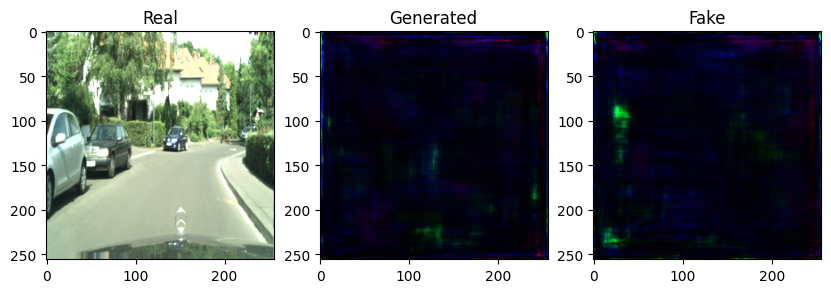

In [ ]:

enc = Encoder(z_dim=z_dim,
                channels=channels,
                block_depth=enc_block_depth,
                residual=enc_residual,
                use_norm = enc_use_norm).to(device)
gen = Generator(z_dim=z_dim,
                channels=channels,
                block_depth=gen_block_depth,
                residual=gen_residual,
                use_norm = gen_use_norm).to(device)

disc = Discriminator(channels=channels,
                     block_depth=disc_block_depth,
                     residual=disc_residual,
                     use_norm=disc_use_norm).to(device)


enc_optimizer = Adam(enc.parameters(), lr=enc_lr, betas=(0.0, 0.9))
gen_optimizer = Adam(gen.parameters(), lr=gen_lr, betas=(0.0, 0.9))
disc_optimizer = Adam(disc.parameters(), lr=disc_lr, betas=(0.0, 0.9))
noise =  torch.randn(1,z_dim,1,1).to(device)
fake = gen(noise)
disc_fake = disc(fake)

real,_ = next(iter(loader))
real = list_to_device(real,device)

encoded_vector = enc(real)
generated_real = gen(encoded_vector)
# disc_real = disc(generated_real)

fig,ax = plt.subplots(1,3,figsize=(10,5))
ax[0].imshow(real[-1][0].cpu().detach().permute(1,2,0).numpy()+1)
ax[0].set_title('Real')
ax[1].imshow(generated_real[-1][0].cpu().detach().permute(1,2,0).numpy()+1)
ax[1].set_title('Generated')
ax[2].imshow(fake[-1][0].cpu().detach().permute(1,2,0).numpy()+1)
ax[2].set_title('Fake')

In [7]:
import torch

def compute_gradient_penalty(critic, real_images, fake_images):
    """
    Calculates the WGAN Gradient Penalty for a Multi-Scale GAN.
    
    Args:
        critic (nn.Module): The discriminator network.
        real_images (list of Tensors): List of real images at different scales.
        fake_images (list of Tensors): List of fake images at different scales.
        
    Returns:
        torch.Tensor: The computed gradient penalty scalar.
    """
    batch_size = real_images[0].shape[0]
    device = real_images[0].device
    
    # 1. Create a single random interpolation weight for the batch
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    
    # 2. Interpolate between real and fake at every scale
    interpolated_images = []
    for real_img, fake_img in zip(real_images, fake_images):
        mixed = (alpha * real_img + (1 - alpha) * fake_img).requires_grad_(True)
        interpolated_images.append(mixed)
        
    # 3. Pass the mixed images through the critic
    mixed_scores = critic(interpolated_images)
    
    # 4. Calculate the gradients of the scores w.r.t the mixed images
    gradients = torch.autograd.grad(
        outputs=mixed_scores,
        inputs=interpolated_images,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )
    
    # 5. Compute the penalty across ALL scales combined
    grad_flat_list = []
    for grad in gradients:
        # Flatten each scale: [batch_size, channels, H, W] -> [batch_size, -1]
        grad_flat_list.append(grad.reshape(batch_size, -1))
        
    # Concatenate all flattened gradients along the feature dimension (dim=1)
    grad_concat = torch.cat(grad_flat_list, dim=1)
    
    # 6. Calculate L2 norm safely (add epsilon inside the square root to prevent NaN)
    # This prevents autograd from crashing if the gradient is exactly zero
    grad_norm = torch.sqrt(torch.sum(grad_concat ** 2, dim=1) + 1e-8)
    
    # 7. Penalize deviation from 1.0
    gradient_penalty = torch.mean((grad_norm - 1.0) ** 2)
        
    return gradient_penalty


In [ ]:
epochs =1000

for epoch in range(0,epochs):
    loop = tqdm(loader)
    loop.set_description("Epoch {}/{}".format(epoch,epochs))

    for i, (real,_) in enumerate(loop):
        real = list_to_device(real,device)
        current_batch_size = real[0].shape[0]
        

        disc_optimizer.zero_grad()

        # train discriminator on fake images (he must tell they are fake)
        with torch.no_grad():
            noise = torch.randn(current_batch_size, z_dim,1,1).to(device)
            fake = gen(noise)
        fake_detached = detach_list(fake)
        disc_fake = disc(fake_detached)

        # train discriminator on encoded images (he must also tell they are fake)
        with torch.no_grad():
            encoded_vector = enc(real)
            encoded_real = gen(encoded_vector)
        disc_encoded_real = disc(encoded_real)
        # train discriminator on real images (he must  tell they are real)
        disc_real = disc(real)
        # Calculate individual loss components
        disc_loss_adv =  (torch.mean(disc_fake) +torch.mean(disc_encoded_real)- torch.mean(disc_real))
        disc_loss_drift = disc_drift_scale * (torch.mean(disc_real ** 2))#s + torch.mean(disc_fake ** 2))
        disc_loss_gp = disc_gp_scale * compute_gradient_penalty(disc, real, fake_detached)
        # Combine and step
        disc_loss = disc_loss_adv + disc_loss_drift +  disc_loss_gp
        disc_loss.backward()
        disc_optimizer.step()

        # train generator & encoder


        gen_optimizer.zero_grad()        
        enc_optimizer.zero_grad()

        noise = torch.randn(current_batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)
        gen_fake_score = disc(fake)
        gen_loss_adv = -torch.mean(gen_fake_score) 

        encoder_latent_vector = enc(real)
        encoded_image = gen(encoder_latent_vector)
        encoded_fake_score = disc(encoded_image)

        enc_loss_adv = - torch.mean(encoded_fake_score)


        # B. Reconstruction & Latent losses
        enc_loss_recon = 0
        for e, r in zip(encoded_image, real):
            enc_loss_recon += enc_rec_scale* F.l1_loss(e, r)
        enc_loss_latent = enc_latent_scale * torch.mean(encoder_latent_vector ** 2)


        enc_loss =enc_loss_adv+  enc_loss_recon +  enc_loss_latent
        # Combine losses into a single backward pass
        loss_gen_enc = gen_loss_adv + enc_loss
        
        loss_gen_enc.backward()
        # IMPORTANT: Step BOTH optimizers so the Generator learns to reconstruct!
        gen_optimizer.step()
        enc_optimizer.step()

     
        loop.set_postfix(loss_disc=disc_loss.item(),loss_gen_enc=loss_gen_enc.item())

        if (i+1) % save_itter == 0:
            torch.save(gen.state_dict(), gen_path)
            torch.save(disc.state_dict(),disc_path)

            epoch_root= '{}'.format(epoch)
            os.makedirs(os.path.join(samples_path,epoch_root),exist_ok=True)
        
            sample_root = os.path.join(epoch_root,'{}'.format(i))
            os.makedirs(os.path.join(samples_path,sample_root),exist_ok=True)
            with torch.no_grad():
                noise = torch.randn(current_batch_size, z_dim,1,1).to(device)
                fake = gen(noise) 
            dimensions = len(fake)

            with torch.no_grad():
                encoder_latent_vector = enc(real)
                encoded_image = gen(encoder_latent_vector)

            for d in range(dimensions):
                fig,ax = plt.subplots(2,3,figsize=(10,5))
                ax[0,0].imshow((real[d][0].permute(1,2,0).cpu().numpy()+1)/2)
                ax[1,0].imshow((real[d][1].permute(1,2,0).cpu().numpy()+1)/2)
                ax[0,1].imshow((encoded_image[d][0].permute(1,2,0).cpu().numpy()+1)/2)
                ax[1,1].imshow((encoded_image[d][1].permute(1,2,0).cpu().numpy()+1)/2)
                ax[0,2].imshow((fake[d][0].permute(1,2,0).cpu().numpy()+1)/2)
                ax[1,2].imshow((fake[d][1].permute(1,2,0).cpu().numpy()+1)/2)
             

                img_path = os.path.join(samples_path,sample_root,'{}.png'.format(d))
                plt.savefig(os.path.join(img_path))
                plt.close()




Epoch 0/1000:   0%|          | 0/1250 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07058823..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0008237362..1.8760782].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0008522868..1.918818].


Text(0.5, 1.0, 'Fake')

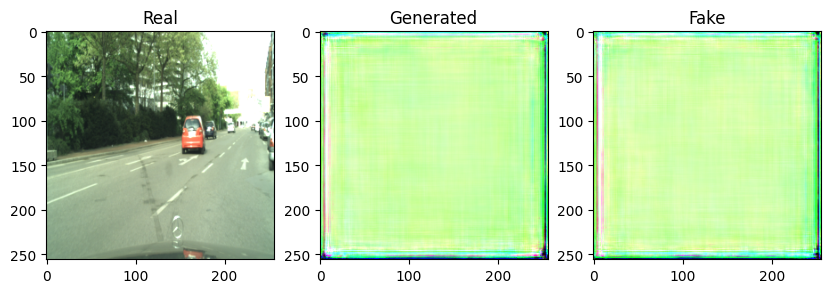

In [11]:
noise =  torch.randn(1,z_dim,1,1).to(device)
fake = gen(noise)
disc_fake = disc(fake)

real,_ = next(iter(loader))
real = list_to_device(real,device)

encoded_vector = enc(real)
generated_real = gen(encoded_vector)
# disc_real = disc(generated_real)

fig,ax = plt.subplots(1,3,figsize=(10,5))
ax[0].imshow(real[-1][0].cpu().detach().permute(1,2,0).numpy()+1)
ax[0].set_title('Real')
ax[1].imshow(generated_real[-1][0].cpu().detach().permute(1,2,0).numpy()+1)
ax[1].set_title('Generated')
ax[2].imshow(fake[-1][0].cpu().detach().permute(1,2,0).numpy()+1)
ax[2].set_title('Fake')

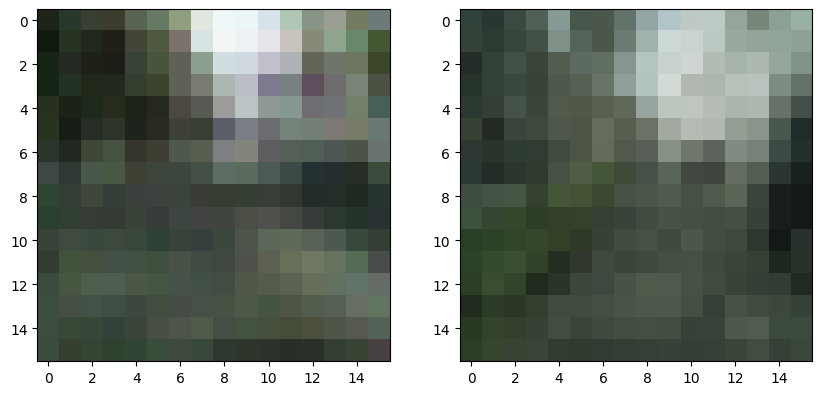

In [ ]:
import matplotlib.pyplot as plt

real,_ =next(iter(loader))
with torch.no_grad():
    noise =torch.randn(8,z_dim,1,1).to(device)
    fake = gen(noise)
fig,ax = plt.subplots(1,2,figsize=(10,5))
show  =2
ax[0].imshow((fake[show][0].permute(1,2,0).cpu().numpy()+1)/2)
ax[1].imshow((real[show][0].permute(1,2,0).cpu().numpy()+1)/2)